# Домашнее задание 3
## Визуализация данных (Титаник)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## 1. Загрузка данных
Считываем датасет Титаника и смотрим что внутри

In [2]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Датасет содержит 891 запись с 12 признаками. Есть пропуски в Age, Cabin, Embarked

## 2. Распределения признаков
Визуализируем распределения для Survived, Pclass, Age, Sex, Parch.
Для категориальных признаков используем столбчатые диаграммы, для числовых - гистограммы

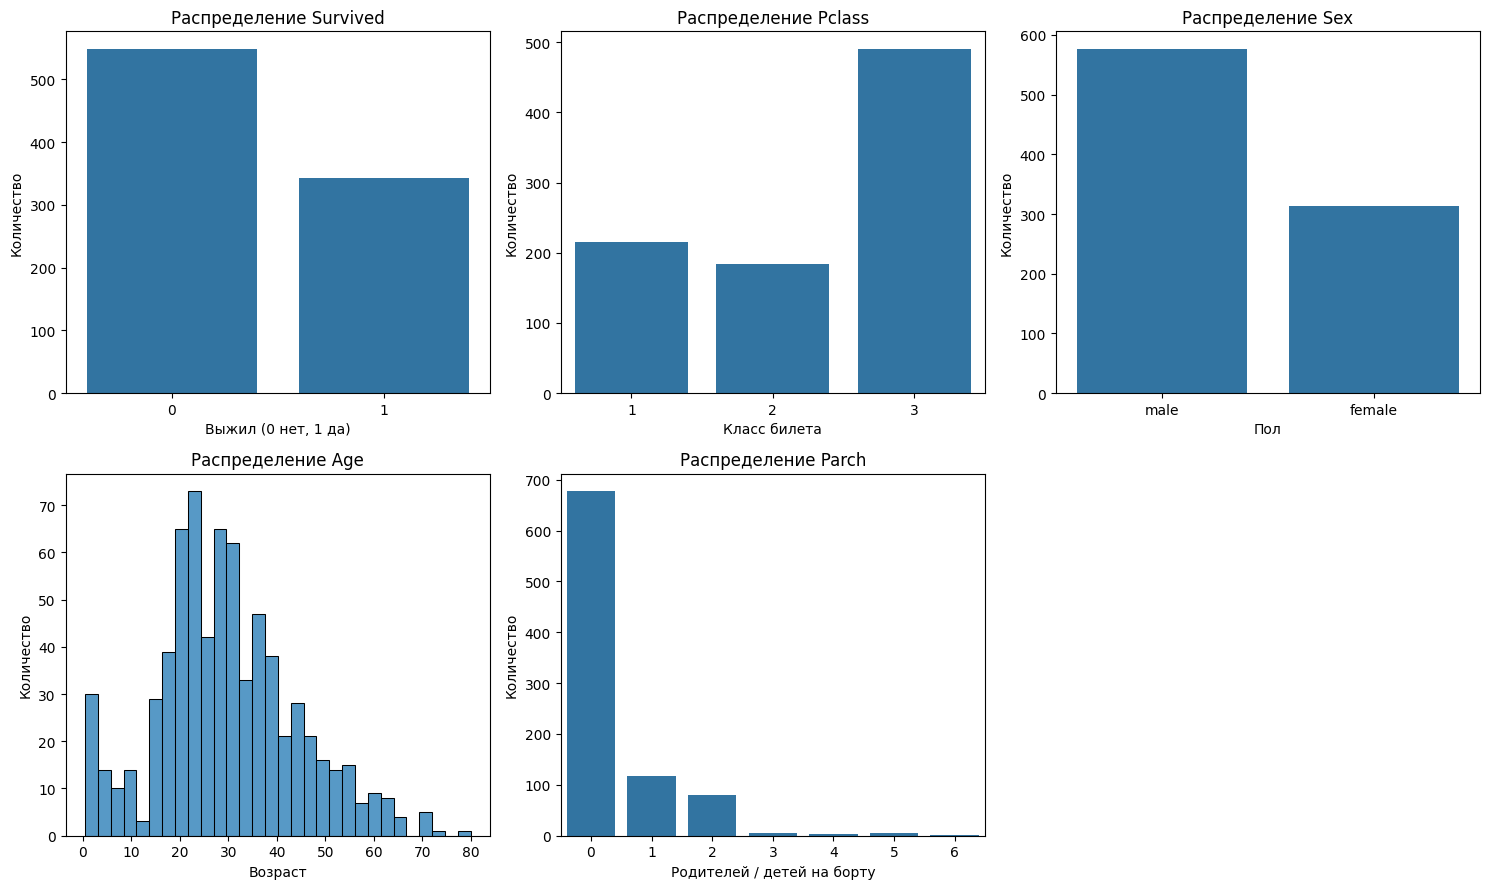

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Survived
sns.countplot(x='Survived', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Распределение Survived')
axes[0, 0].set_xlabel('Выжил (0 нет, 1 да)')
axes[0, 0].set_ylabel('Количество')

# Pclass
sns.countplot(x='Pclass', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Распределение Pclass')
axes[0, 1].set_xlabel('Класс билета')
axes[0, 1].set_ylabel('Количество')

# Sex
sns.countplot(x='Sex', data=df, ax=axes[0, 2])
axes[0, 2].set_title('Распределение Sex')
axes[0, 2].set_xlabel('Пол')
axes[0, 2].set_ylabel('Количество')

# Age
sns.histplot(df['Age'].dropna(), bins=30, ax=axes[1, 0])
axes[1, 0].set_title('Распределение Age')
axes[1, 0].set_xlabel('Возраст')
axes[1, 0].set_ylabel('Количество')

# Parch
sns.countplot(x='Parch', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Распределение Parch')
axes[1, 1].set_xlabel('Родителей / детей на борту')
axes[1, 1].set_ylabel('Количество')

# убираем пустой subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

Что видим:
- Не выжило больше людей, чем выжило
- Больше всего пассажиров 3-го класса
- Мужчин на борту было значительно больше, чем женщин
- Возраст в основном 20-40 лет, распределение немного смещено вправо
- Большинство пассажиров ехали без родителей/детей (Parch = 0)

## 3. Boxplot для Age
Строим график для Age, чтобы увидеть медиану, квартили и выбросы

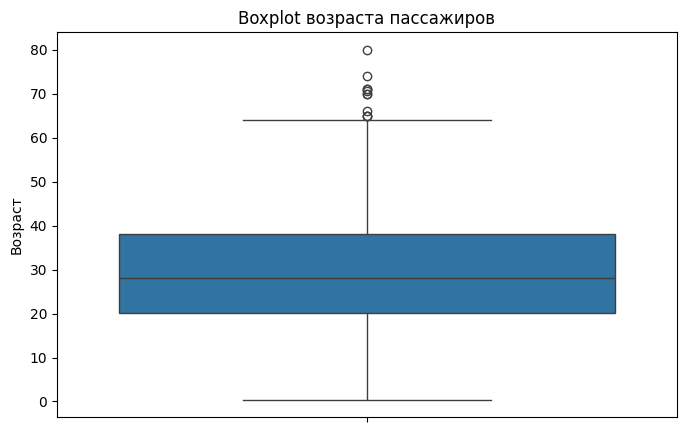

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Age'])
plt.title('Boxplot возраста пассажиров')
plt.ylabel('Возраст')
plt.show()

### Интерпретация boxplot

- **Медиана** (линия внутри ящика) - около 28 лет, то есть половина пассажиров младше 28 лет
- **Нижний квартиль (Q1)** — около 20 лет, **верхний квартиль (Q3)** — около 38 лет. Значит 50% пассажиров были в возрасте от 20 до 38 лет
- **Усы** тянутся примерно от 0 до 65 лет
- **Выбросы** - точки выше верхнего уса, это пассажиры старше ~65 лет. Их немного, это пожилые люди
- В целом распределение возраста немного скошено вправо - есть хвост в сторону пожилых пассажиров

## 4. Pie chart для Survived и Pclass
Круговые диаграммы с процентами.

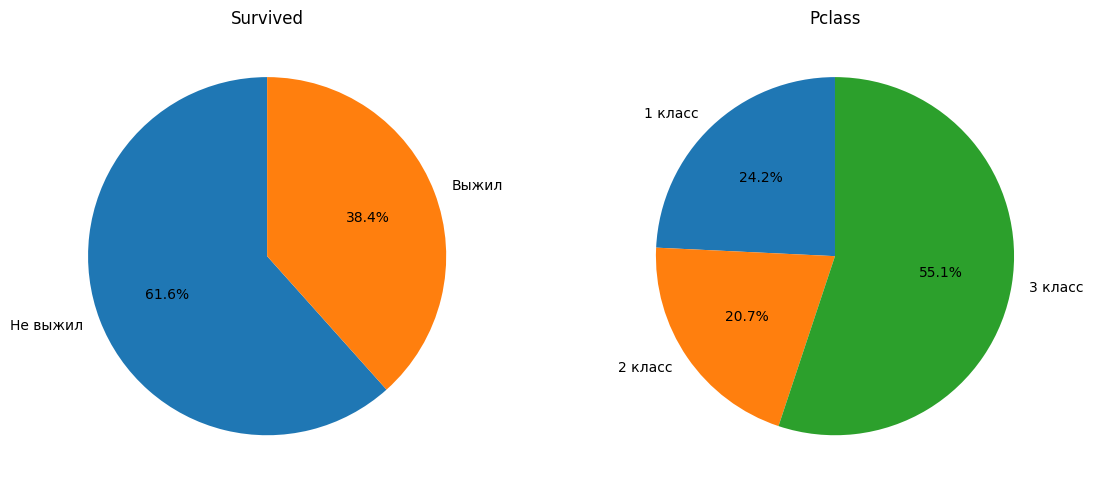

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Survived
surv_counts = df['Survived'].value_counts()
axes[0].pie(surv_counts, labels=['Не выжил', 'Выжил'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Survived')

# Pclass
pclass_counts = df['Pclass'].value_counts().sort_index()
axes[1].pie(pclass_counts, labels=['1 класс', '2 класс', '3 класс'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Pclass')

plt.tight_layout()
plt.show()

- Погибших - около 61.6%, выживших - 38.4%
- Больше всего пассажиров 3-го класса ~55%, первый класс ~24%, второй ~21%

## 5. Pairplot для числовых переменных
Строим pairplot по всем числовым столбцам

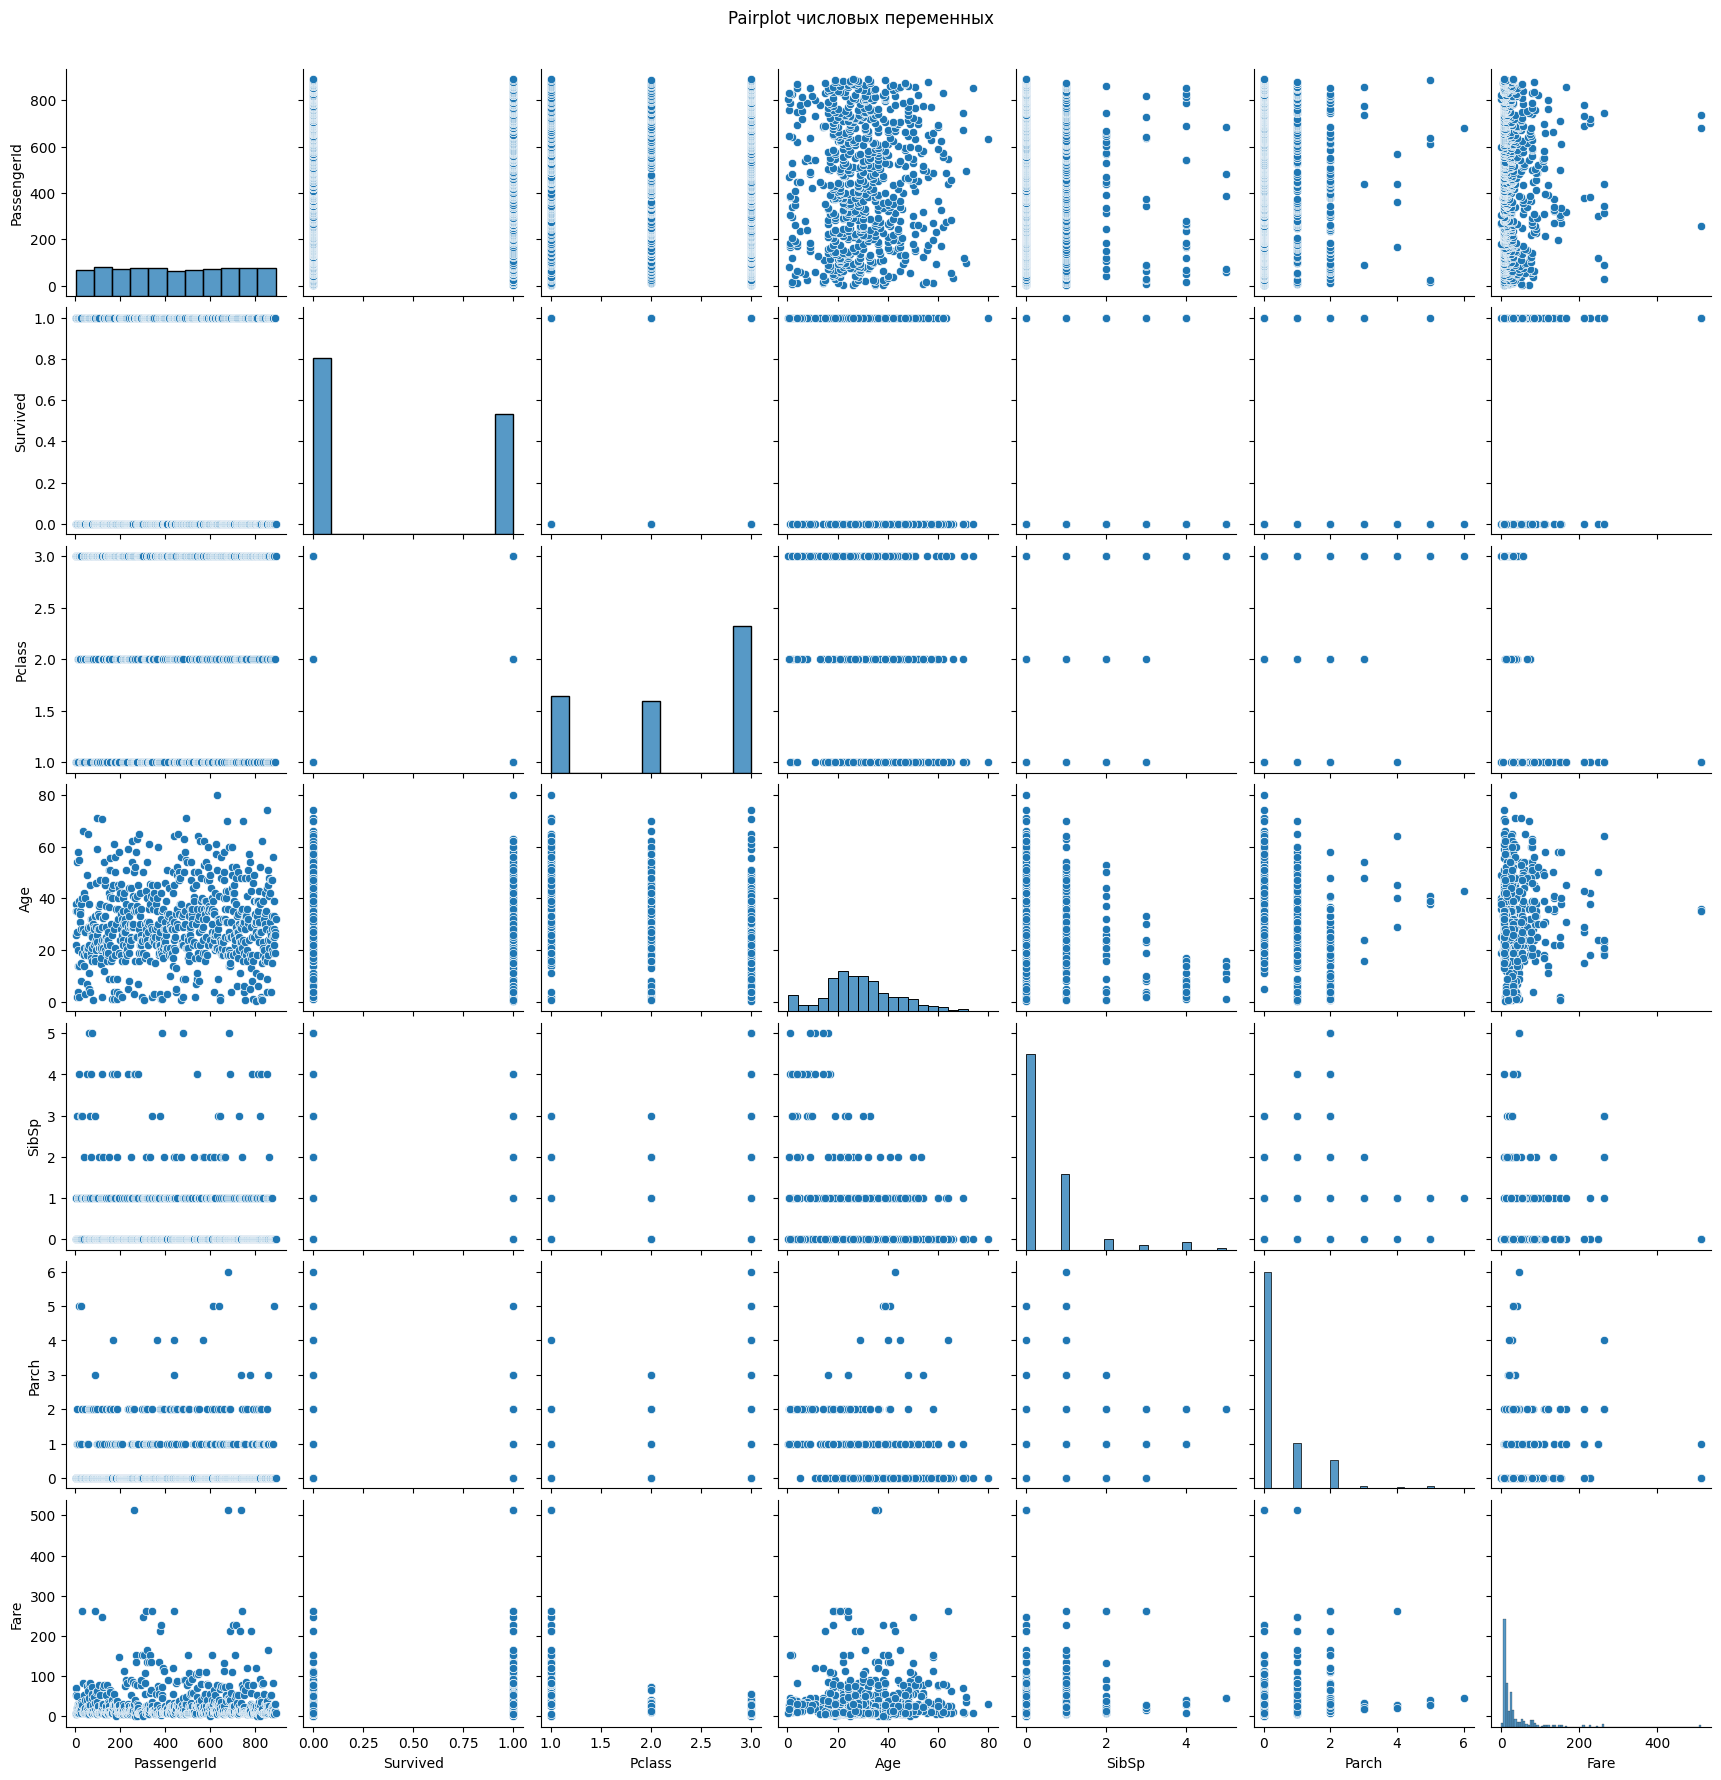

In [8]:
num_cols = df.select_dtypes(include='number').columns.tolist()
sns.pairplot(df[num_cols].dropna())
plt.suptitle('Pairplot числовых переменных', y=1.02)
plt.show()

На pairplot видно, что большинство числовых признаков не имеют ярко выраженных линейных зависимостей друг с другом. Fare имеет сильно скошенное распределение с выбросами. Pclass и Fare немного связаны - чем выше класс, тем выше цена билета.

## 6. Violin plot: Age по Sex
Смотрим как распределяется возраст у мужчин и женщин

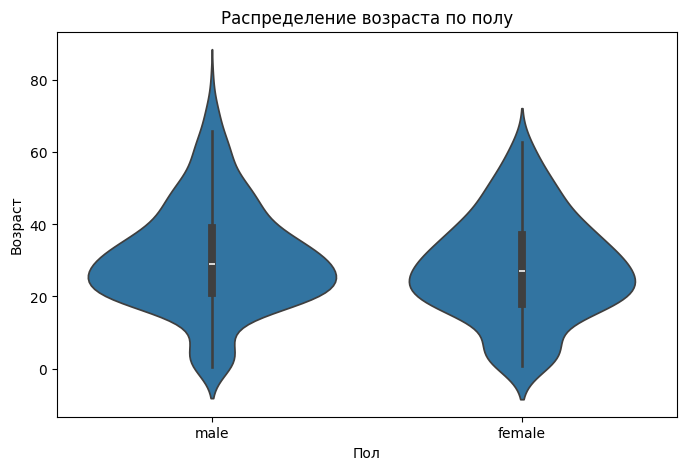

In [9]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='Sex', y='Age', data=df)
plt.title('Распределение возраста по полу')
plt.xlabel('Пол')
plt.ylabel('Возраст')
plt.show()

Распределение возраста у мужчин и женщин похожее, основная масса пассажиров в диапазоне 20-40 лет. У мужчин чуть более широкий разброс и больше пассажиров в районе 20-30 лет. У женщин форма более равномерная.

## 7. Heatmap корреляционной матрицы
Считаем корреляции между числовыми признаками и рисуем тепловую карту

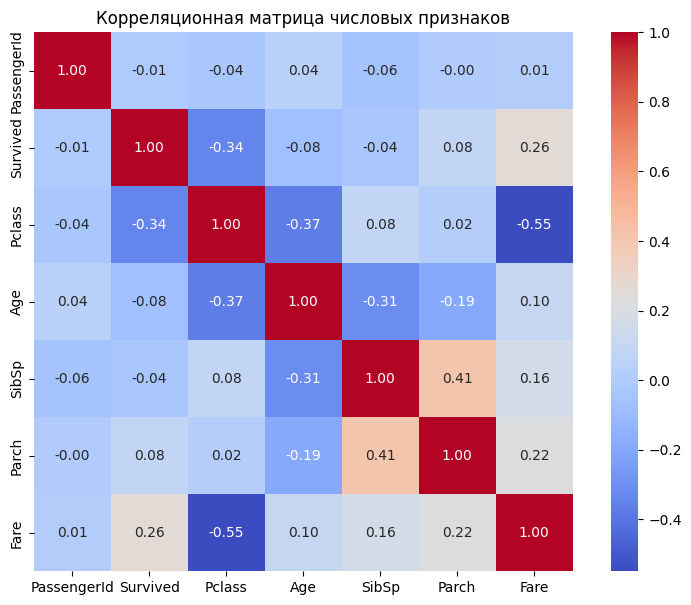

In [10]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

Заметные корреляции:
- **Pclass и Fare** - отрицательная корреляция (чем ниже номер класса - чем выше класс, тем дороже билет)
- **SibSp и Parch** - небольшая положительная корреляция
- **Survived и Pclass** - отрицательная (пассажиры 1-го класса выживали чаще)
- **Survived и Fare** - положительная

## 8. Sunburst plot (plotly)
Интерактивный график: первый уровень - класс, второй - пол внутри класса

In [11]:
sunburst_df = df.groupby(['Pclass', 'Sex']).size().reset_index(name='count')
sunburst_df['Pclass'] = sunburst_df['Pclass'].map({1: '1 класс', 2: '2 класс', 3: '3 класс'})

fig = px.sunburst(
    sunburst_df,
    path=['Pclass', 'Sex'],
    values='count',
    title='Количество пассажиров по классу и полу'
)
fig.show()

На sunburst видно, что в 3-м классе больше всего пассажиров, причём мужчин в каждом классе значительно больше, чем женщин.
Наибольший разрыв между мужчинами и женщинами - именно в 3-м классе.